# tmp — feb25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')
cfg_vae['n_iters_inner'] = 2

mod = IPVAE(ConfigPoisVAE(**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

In [4]:
mod.cfg.name()

'vH16_t-32[§4]×2_b-1_z-[512]_<grad|lin>'

In [5]:
print(mod.cfg.name())

vH16_t-32[§4]×2_b-1_z-[512]_<grad|lin>

In [6]:
mod.cfg.sequences

{0: range(0, 8), 1: range(8, 16), 2: range(16, 24), 3: range(24, 32)}

In [10]:
seq_len = 32
n_iters_outer = 4

str_t = f"t-{seq_len}"
str_t = f"{str_t}[/{n_iters_outer}]"

In [11]:
str_t

't-32[/4]'

In [3]:
from base.helper import conv_arithmetic

In [10]:
conv_arithmetic(input_size=8, output_size=16, kernel_size=None, stride=1, padding=0, deconv=True)

9

In [11]:
conv_arithmetic(input_size=1, output_size=16, kernel_size=None, stride=1, padding=0, deconv=True)

16

In [3]:
torch.optim.Optimizer()

torch.optim.optimizer.Optimizer

In [4]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 8
cfg_vae['n_iters'] = 1

# cfg_vae['init_scale'] = 1e-2
# cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 10.0
# cfg_tr['optimizer'] = 'schedulefree'

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 8, 'n_iters': 1}

Trainer:
{'batch_size': 200, 'epochs': 300, 'grad_clip': 200, 'kl_beta': 10.0}

In [5]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

In [6]:
tr.optim

Adamax (
Parameter Group 0
    betas: (0.9, 0.999)
    eps: 1e-08
    initial_lr: 0.002
    lr: 0.002
    weight_decay: 0.0003
)

AdamWScheduleFree (
Parameter Group 0
    betas: (0.9, 0.999)
    eps: 1e-08
    foreach: True
    k: 0
    lr: 0.002
    lr_max: -1.0
    r: 0.0
    scheduled_lr: 0.0
    train_mode: False
    warmup_steps: 0
    weight_decay: 0.0003
    weight_lr_power: 2.0
    weight_sum: 0.0
)

In [6]:
state_dict = tr.optim.state_dict()
for g in state_dict['param_groups']:
    g['warmup_steps'] = 123
tr.optim.load_state_dict(state_dict)

In [15]:
tr.cfg.warmup_portion * tr.n_iters

772.5

In [6]:
from schedulefree import AdamWScheduleFree

In [7]:
AdamWScheduleFree()

TypeError: AdamWScheduleFree.__init__() missing 1 required positional argument: 'params'

In [4]:
schedulefree.AdamWScheduleFree()

TypeError: AdamWScheduleFree.__init__() missing 1 required positional argument: 'params'

In [21]:
deconv = nn.ConvTranspose2d(512, 1, 9, stride=1, padding=0)

In [22]:
b = 123
z = torch.randn(b, 512, 8, 8)

In [23]:
pred = deconv(z)
pred.shape

torch.Size([123, 1, 16, 16])

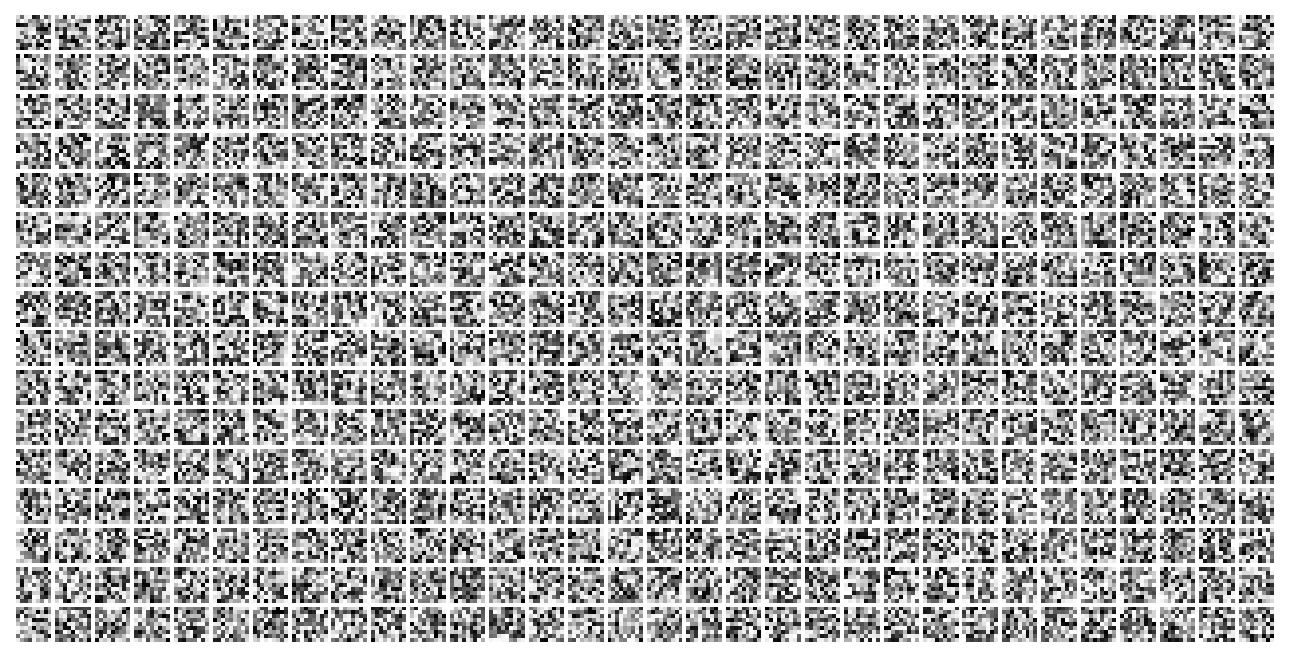

(<Figure size 1280x640 with 1 Axes>, <Axes: >)

In [26]:
plot_weights(deconv.weight.squeeze())

In [3]:
model_str = '/'.join([
    'poisson_vH16_t-8×1_z-[512]_<grad|lin>',
    'b200-ep300-lr(0.002)_beta(16:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_08,14:09)',
])
tr, meta = load_quick(model_str, False)

In [4]:
meta

{'timestamp': '2025_02_08,14:09',
 'checkpoint': 11,
 'global_step': 5665,
 'root': '/home/hadi/Projects/PoissonVAE/models/poisson_vH16_t-8×1_z-[512]_<grad|lin>/b200-ep300-lr(0.002)_beta(16:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_08,14:09)',
 'file': 'IPVAE+Trainer-0011_(2025_02_08,14:14).pt'}

In [7]:
model_type = 'poisson'

tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](dataset='MNIST-rotate', kws_feeder={'theta_0': 0})),
    cfg=ConfigTrain(batch_size=200, epochs=20, kl_beta=0.001),
    device=device,
)

# cfg_vae, cfg_tr = default_configs('EyeMovies16', model_type, 'lin|lin')

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'leapfrog|lin')

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'leapfrog', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001}

Trainer:
{'batch_size': 200, 'epochs': 300, 'grad_clip': 200}

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

In [5]:
tr.optim

Adamax (
Parameter Group 0
    betas: (0.9, 0.999)
    eps: 1e-08
    initial_lr: 0.002
    lr: 0.002
    weight_decay: 0.0003
)

In [7]:
tr.cfg.optimizer_kws

{'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}

In [11]:
tr.optim

Adamax (
Parameter Group 0
    betas: (0.9, 0.999)
    eps: 1e-08
    initial_lr: 0.002
    lr: 0.002
    weight_decay: 0.0
)

In [10]:
tr.optim.train()

AttributeError: 'Adamax' object has no attribute 'train'

In [7]:
tr.dl_vld.dataset.theta_0, tr.dl_vld.dataset.delta_theta

(0, 8)

In [8]:
tr.train()

epoch # 20, avg loss: 1238.720482: 100%|███████| 20/20 [59:40<00:00, 179.01s/it]


In [6]:
x, y, *_ = next(iter(tr.dl_vld))
output = tr.model(x, y.flatten(start_dim=1))

In [7]:
cond = output['conditional']

In [8]:
cond.loc

tensor([[-8.4361e-05, -2.0653e-04, -9.3973e-05,  ..., -1.4286e-05,
         -3.5837e-05, -3.9992e-05],
        [-3.8605e-05, -1.5924e-05,  8.0835e-05,  ...,  2.0899e-04,
         -2.9748e-05,  9.2412e-05],
        [-5.6172e-05, -2.9822e-05, -2.7290e-06,  ...,  3.6226e-05,
         -2.5718e-05,  1.1974e-06],
        ...,
        [-3.5661e-06, -5.8144e-05,  1.3343e-04,  ...,  3.0477e-04,
         -8.5549e-05,  2.3532e-04],
        [-5.5084e-05, -7.8485e-05,  4.4637e-05,  ...,  1.8457e-04,
         -1.5620e-05, -2.7752e-05],
        [-1.9934e-04, -3.3223e-04,  1.6135e-04,  ...,  2.4723e-06,
         -2.0970e-04, -1.9030e-04]], device='cuda:0', grad_fn=<MmBackward0>)

In [9]:
cond.loc.shape

torch.Size([200, 784])

In [10]:
y.shape

torch.Size([200, 1, 28, 28])

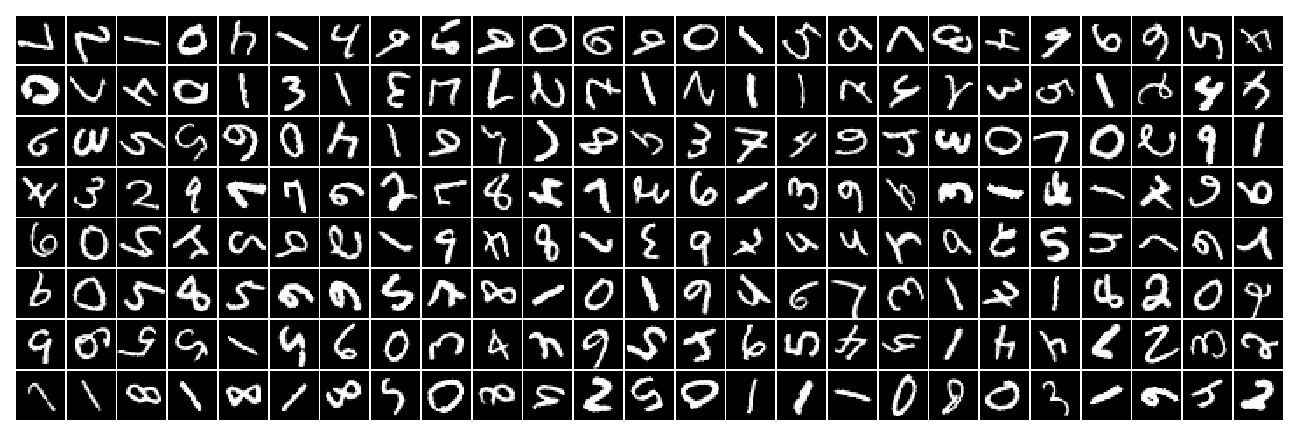

In [12]:
_ = plot_weights(y.squeeze(), method='none', nrows=8)

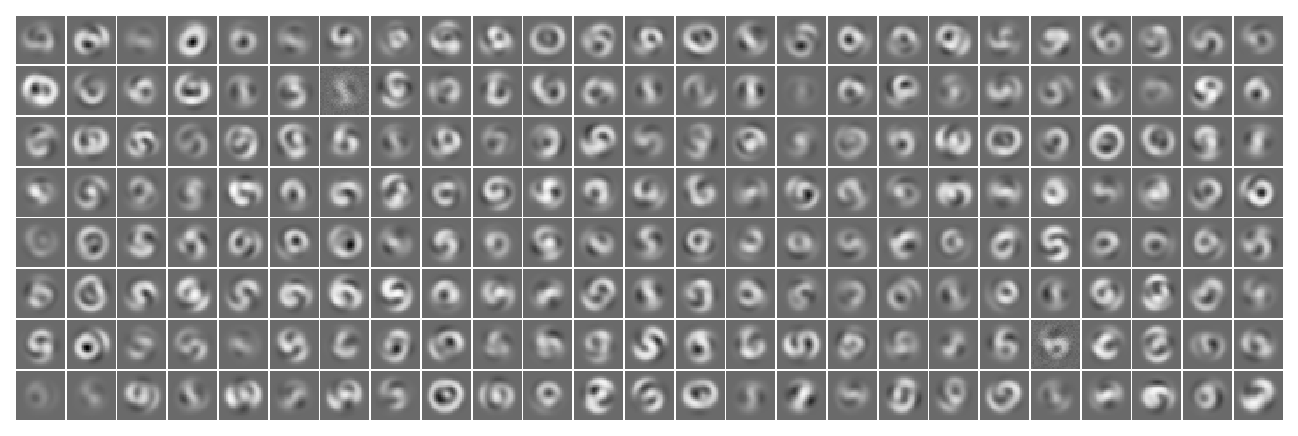

In [13]:
shape = (-1, tr.model.cfg.npix, tr.model.cfg.npix)
_ = plot_weights(cond.loc.reshape(shape), method='none', nrows=8)

In [6]:
model_type = 'poisson'

tr = TrainerVIB(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](dataset='CIFAR10')),
    cfg=ConfigTrainVIB(batch_size=200, epochs=100, kl_beta=0.001),
    device=device,
)

# cfg_vae, cfg_tr = default_configs('EyeMovies16', model_type, 'lin|lin')

In [3]:
from base.dataset import make_dataloader

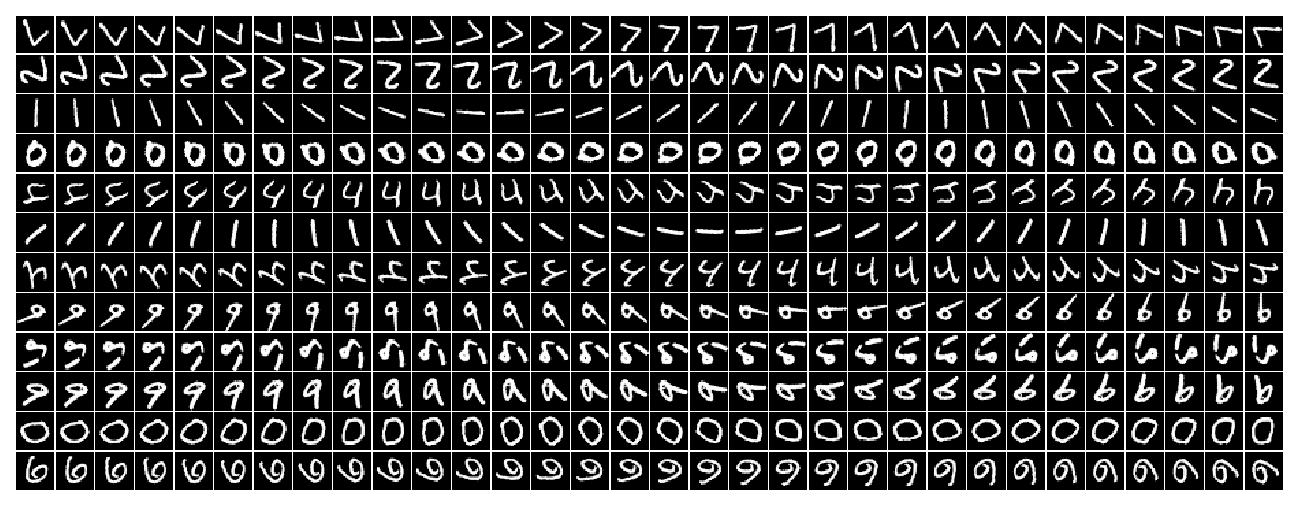

In [9]:
_, vld = make_dataloader('RotatingMNIST', device, tau_context=32)

x, y, g = next(iter(vld))

num = 12
x2p = x[:num].view(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num)

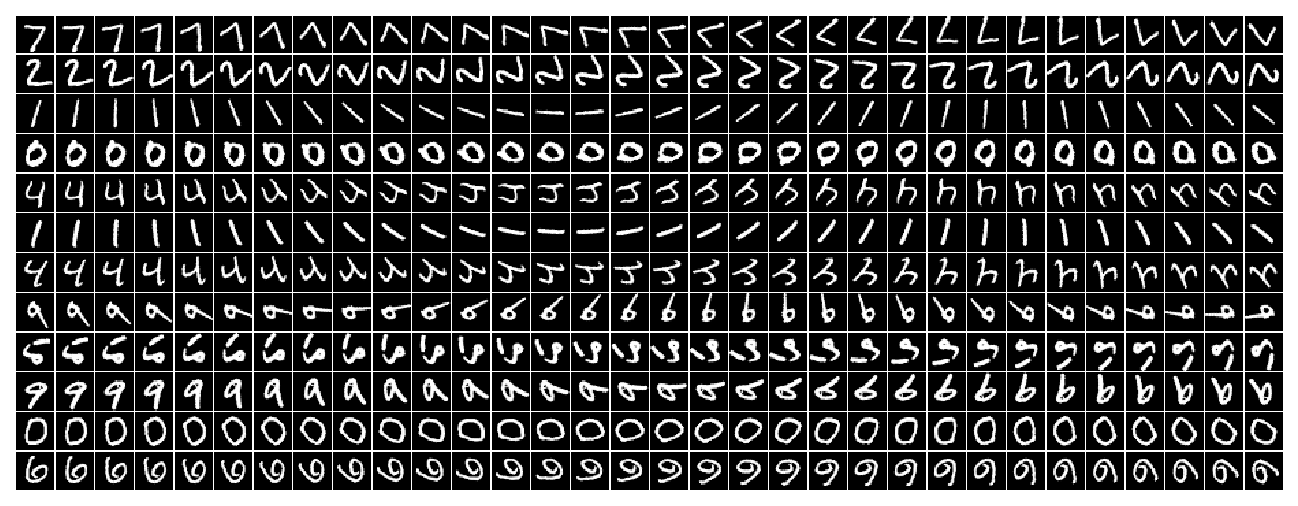

In [10]:
_, vld = make_dataloader('RotatingMNIST', device, tau_context=32, theta_0=0)

x, y, g = next(iter(vld))

num = 12
x2p = x[:num].view(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num)

In [3]:
from base.dataset import make_dataloader, rotate_img

_, vld = make_dataloader('MNIST', device)

In [4]:
x, g = next(iter(vld))
x_rot = rotate_img(x, 45, hist_match=False)
x_rot_matched = rotate_img(x, 45, hist_match=True)

x.shape

torch.Size([256, 1, 28, 28])

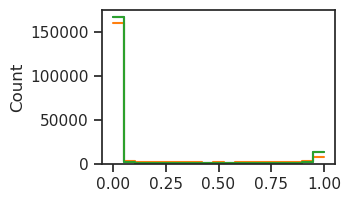

In [5]:
histplot(x.ravel())
histplot(x_rot.ravel())
histplot(x_rot_matched.ravel());

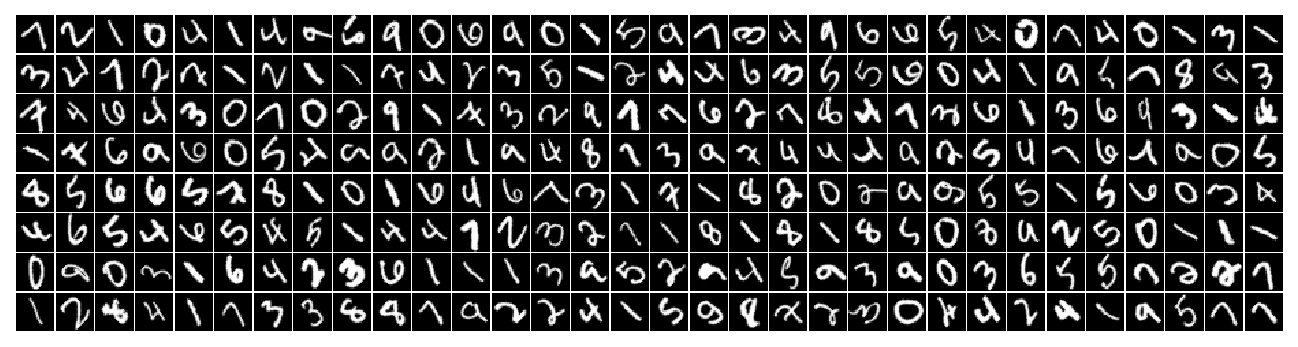

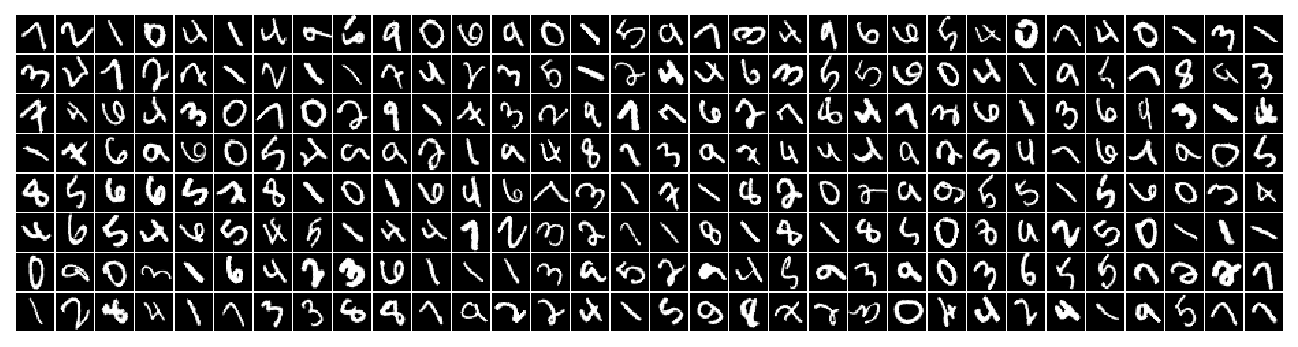

In [6]:
_ = plot_weights(x_rot, method='none', nrows=8)
_ = plot_weights(x_rot_matched, method='none', nrows=8)

In [7]:
%timeit rotate_img(x, 45, hist_match=False)

281 µs ± 1.03 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [12]:
%timeit rotate_img(x, 45, hist_match=True)

273 µs ± 393 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [13]:
x.shape

torch.Size([256, 1, 28, 28])

In [15]:
_ = rotate_img(x[0], 45)

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_EyeMovies16_z-512_tau-[10,1]_<lin|lin>
b200-ep100-lr(0.002)_beta(0.001:0x0.1)_temp(0.05:lin-0.5)_gr(500)

In [6]:
tr.train()

epoch # 100, avg loss: 398.533271: 100%|██████| 100/100 [11:48<00:00,  7.08s/it]


In [7]:
data, loss, etc = tr.forward('vld')

In [8]:
loss['recon']

array([0.10998048, 0.1092962 , 0.08307579, ..., 3.773471  , 3.9062846 ,
       4.4586954 ], dtype=float32)

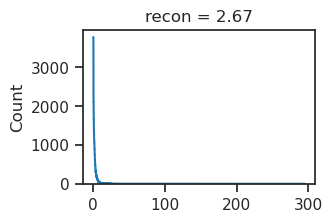

In [9]:
ax = histplot(loss['recon'])
ax.set_title(f"recon = {loss['recon'].mean():0.2f}")
plt.show()

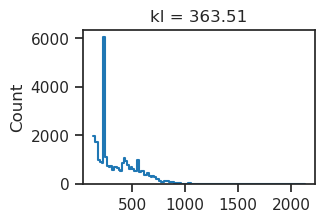

In [10]:
ax = histplot(loss['kl'])
ax.set_title(f"kl = {loss['kl'].mean():0.2f}")
plt.show()

In [11]:
layer = tr.model.layer
dec = tr.model.dec

In [12]:
torch.exp(dec.log_scale).shape

torch.Size([1, 256])

In [13]:
x, y = next(iter(tr.dl_vld))
output = tr.model(x, y.flatten(start_dim=1))

In [14]:
cond = output['conditional']

In [15]:
cond.loc

tensor([[ 0.0311,  0.0306,  0.0304,  ...,  0.0368,  0.0370,  0.0377],
        [-0.0263, -0.0247, -0.0234,  ..., -0.0082, -0.0076, -0.0085],
        [ 0.0764,  0.0756,  0.0744,  ...,  0.0724,  0.0751,  0.0768],
        ...,
        [ 0.2366,  0.2286,  0.2249,  ...,  0.4305,  0.4384,  0.4438],
        [ 0.2191,  0.2160,  0.2172,  ...,  0.4316,  0.4432,  0.4487],
        [ 0.1996,  0.1946,  0.1960,  ...,  0.4710,  0.4872,  0.4970]],
       device='cuda:0', grad_fn=<MmBackward0>)

In [16]:
cond.loc.shape

torch.Size([200, 256])

In [17]:
y.shape

torch.Size([200, 1, 16, 16])

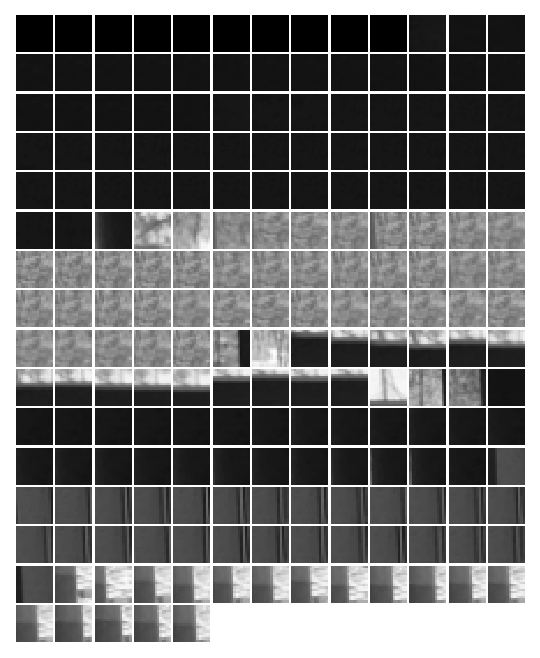

In [18]:
_ = plot_weights(y.squeeze(), method='none')

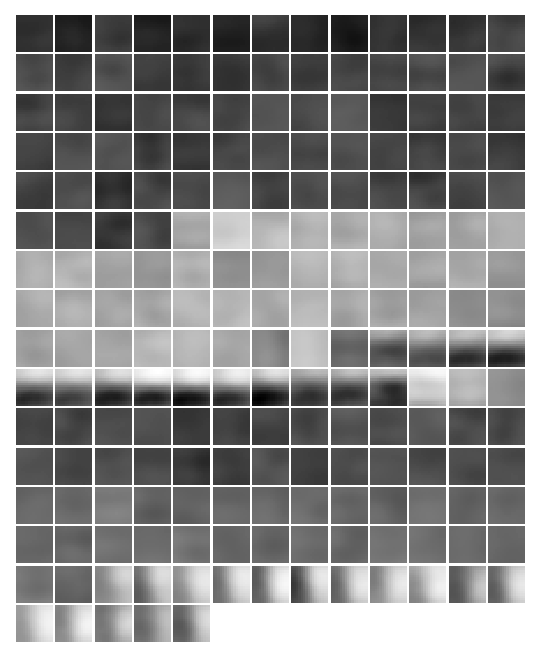

In [19]:
_ = plot_weights(cond.loc.reshape(-1, 16, 16), method='none')

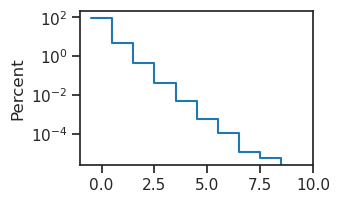

In [23]:
spks = data['z'].ravel()
ax = histplot(spks, stat='percent', bins=np.linspace(0, 10, 11) - 0.5)
ax.set(yscale='log')
plt.show()

In [5]:
data, loss, etc = tr.validate() # tr.forward('vld')

In [6]:
list(data)

['x', 'y', 'z', 'pred']

In [7]:
collections.Counter(data['z'].ravel().astype(int))

Counter({0: 16900146, 1: 599819, 2: 21505, 3: 689, 4: 16, 5: 1})

<Axes: ylabel='Count'>

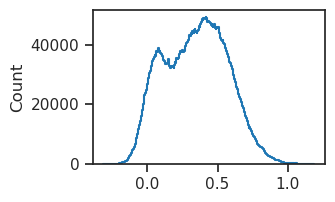

In [20]:
histplot(data['pred'].ravel())

<Axes: ylabel='Count'>

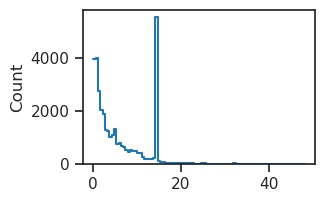

In [21]:
histplot(loss['kl'])

<Axes: ylabel='Count'>

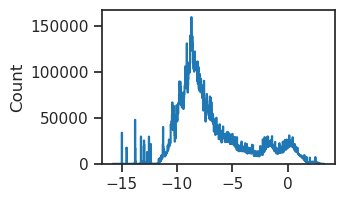

In [22]:
histplot(etc['u+du'].ravel())

In [25]:
w = tr.model.dec.phi.weight.data
w = tonp(w.T.reshape(-1, 16, 16))
w.shape

(512, 16, 16)

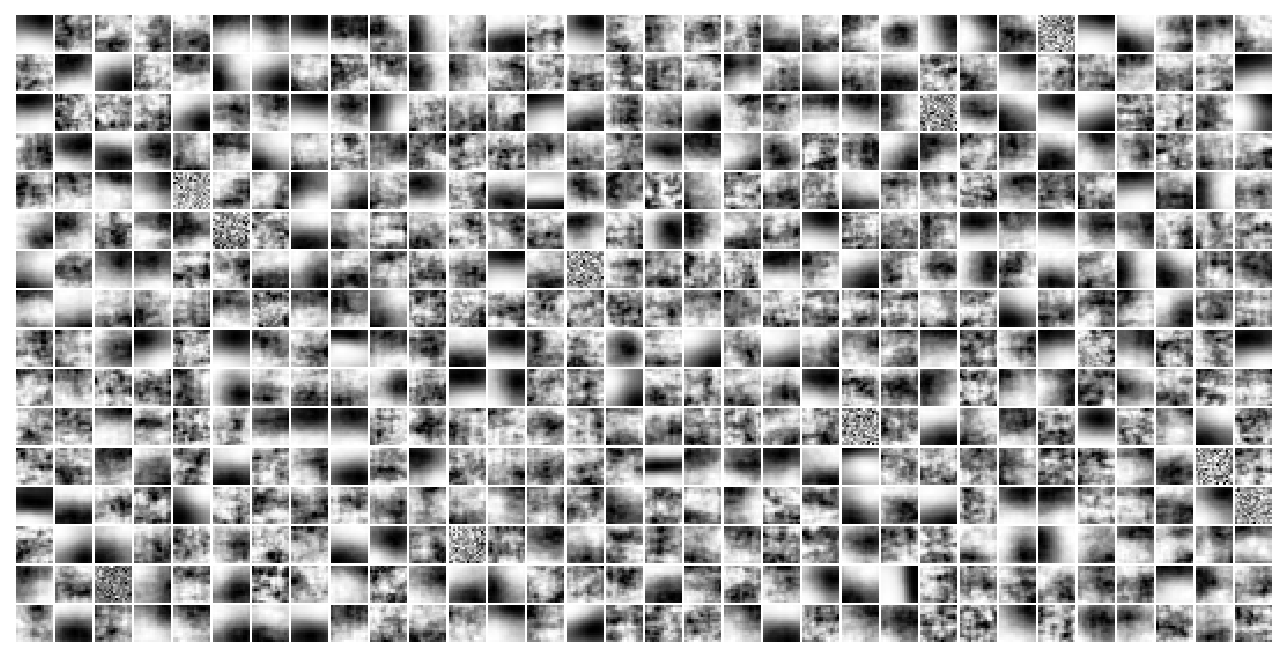

In [26]:
_ = plot_weights(w)

In [27]:
t_kers = tr.model.layer.enc.conv_t.weight.data
s_kers = tr.model.layer.enc.conv_s.weight.data

t_kers = tonp(t_kers.squeeze())
s_kers = tonp(s_kers.squeeze())

t_kers.shape, s_kers.shape

((512, 10), (512, 16, 16))

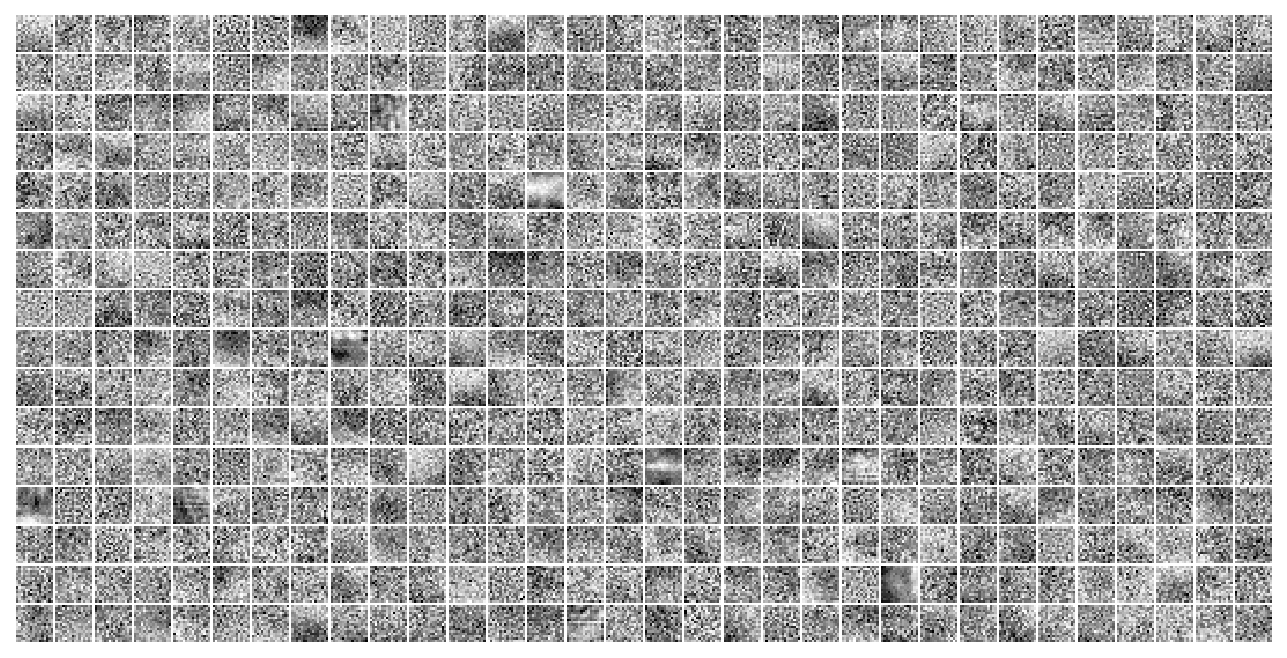

In [28]:
_ = plot_weights(s_kers)

<Axes: ylabel='Count'>

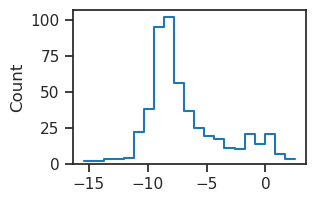

In [29]:
u = tonp(tr.model.layer.log_rate.squeeze())
histplot(u)

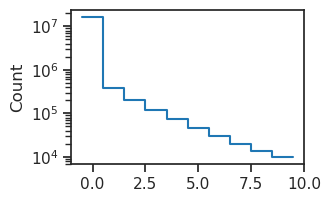

In [3]:
from base.utils_model import print_num_params

from main.config_vib import ConfigPoisVIB
from main.vib import PoissonVIB

In [4]:
cfg = ConfigPoisVIB(save=False)
pvib = PoissonVIB(cfg).to(device)

print(cfg.name())
print(pvib)

poisson_EyeMovies16_z-512_tau-[10,1]_<lin|lin>

PoissonVIB(
  (layer): PoissonLayer(tau=[10,1], temp=1, beta=1)
  (dec): LinearGausDecoder(
    (phi): LinearDictionary()
  )
)

In [5]:
batch_size = 123

shape = (batch_size, *cfg.shape[1:])
x = torch.randn(shape).to(device)

shape = (batch_size, pvib.cfg.tau_pred, *cfg.shape[2:])
y = torch.randn(shape).to(device)
y = y.flatten(start_dim=1)

x.shape, y.shape

(torch.Size([123, 10, 16, 16]), torch.Size([123, 256]))

In [6]:
output = pvib(x, y)

In [7]:
list(output)

['loss_kl', 'loss_recon', 'conditional', 'posterior', 'pred', 'z']

In [8]:
output['loss_kl'].shape, output['loss_recon'].shape

(torch.Size([123]), torch.Size([123]))

In [9]:
posterior = output['posterior']

In [11]:
posterior.n_exp

271

In [15]:
pvib.cfg.input_sz

(10, 16, 16)

In [ ]:
div = pvib.cfg.npix ** 2
div *= pvib.cfg.tau_pred

(torch.Size([123, 4096]), torch.Size([123, 512]))

In [27]:
conditional

Normal(loc: torch.Size([123, 4096]), scale: torch.Size([123, 4096]))

In [28]:
posterior

<Axes: ylabel='Count'>

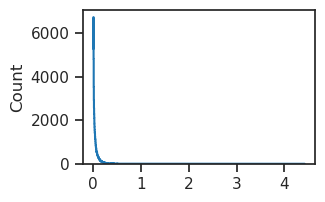

In [32]:
histplot(posterior.rate.ravel())

In [9]:
print_num_params(pois)
print_num_params(pois.enc)
print_num_params(pois.dec)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  4.2 Mil   |
|     ———      |    ———     |
|     enc      |  2.1 Mil   |
|     dec      |  2.1 Mil   |
+--------------+------------+

+------------------+------------+
|   Module Name    | Num Params |
+------------------+------------+
| LinearSepEncoder |  2.1 Mil   |
|       ———        |    ———     |
|      conv_t      |   5.6 K    |
|      conv_s      |  2.1 Mil   |
+------------------+------------+

+-------------------+------------+
|    Module Name    | Num Params |
+-------------------+------------+
| LinearGausDecoder |  2.1 Mil   |
|        ———        |    ———     |
|        phi        |  2.1 Mil   |
+-------------------+------------+

In [4]:
print(cfg.name())

poisson_EyeMovies_t-10_z-512_<lin|lin>

In [5]:
from main.layers import LinearSepEncoder, LinearGausDecoder, LinearDictionary

In [6]:
enc = LinearSepEncoder(10, 64, 512).to(device)
dec = LinearGausDecoder(512, 64 ** 2 * 1, cfg).to(device)
# phi = LinearDictionary()

In [7]:
dec.phi.weight.shape

torch.Size([4096, 512])

In [8]:
x = torch.randn(123, 10, 64, 64).to(device)

In [9]:
du = enc(x)
dr = torch.exp(du)
conditional, pred = dec(dr)

dr.shape, pred.shape

(torch.Size([123, 512]), torch.Size([123, 4096]))

In [12]:
print_num_params(enc)

+------------------+------------+
|   Module Name    | Num Params |
+------------------+------------+
| LinearSepEncoder |  2.1 Mil   |
|       ———        |    ———     |
|      conv_t      |   5.6 K    |
|      conv_s      |  2.1 Mil   |
+------------------+------------+

In [13]:
print_num_params(dec)

+-------------------+------------+
|    Module Name    | Num Params |
+-------------------+------------+
| LinearGausDecoder |  2.1 Mil   |
|        ———        |    ———     |
|        phi        |  2.1 Mil   |
+-------------------+------------+

In [10]:
end.conv_t.weight.shape

torch.Size([512, 10, 1, 1])

In [11]:
end.conv_s.weight.shape

torch.Size([512, 1, 64, 64])

In [3]:
file_path = 'Datasets/EyeMovies/Allen_2022-04-13b_movie.h5'
file_path = add_home(file_path)

In [4]:
file = h5py.File(file_path, 'r')

In [5]:
list(file)

['eye_pos', 'movies', 't_samples', 'trials']

In [6]:
x = np.array(file['movies'])
x.shape

(171170, 64, 64)

In [7]:
from utils.animation import show_movie

In [8]:
show_movie(x[range(500, 600)])

In [9]:
show_movie(x[range(2500, 2600)])